Voxel grid shape: (50, 50, 50)
Number of voxels inside ellipsoid: 8405


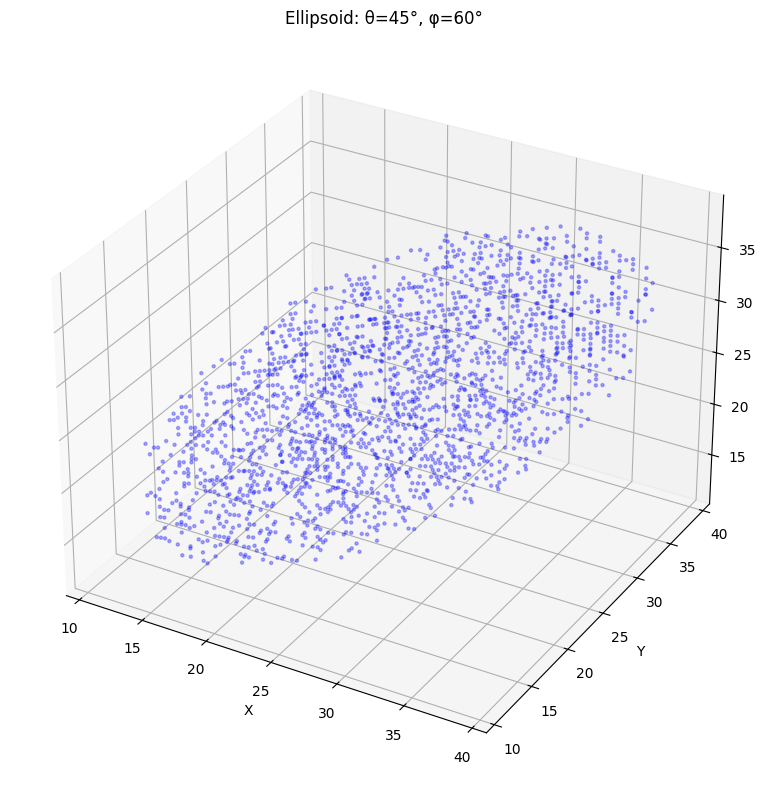

In [1]:
import numpy as np

def create_ellipsoid_voxels(n, center, long_diameter, short_diameter, theta, phi):
    """
    Create a 3D voxel array with 1s inside an ellipsoid and 0s outside.
    
    Parameters:
    -----------
    n : int
        Size of the voxel grid (NxNxN)
    center : tuple of 3 floats
        (cx, cy, cz) - center of the ellipsoid in voxel coordinates
    long_diameter : float
        Diameter along the long (principal) axis
    short_diameter : float
        Diameter along both short axes (spheroid)
    theta : float
        Azimuthal angle in radians - rotation of long axis in the x-y plane 
        (0 = pointing along x, pi/2 = pointing along y)
    phi : float
        Polar angle in radians - angle of long axis from the z-axis
        (0 = pointing along z, pi/2 = in the x-y plane)
    
    Returns:
    --------
    voxels : ndarray
        NxNxN array of uint8 with 1 inside ellipsoid, 0 outside
    """
    # Convert diameters to semi-axes (radii)
    a = long_diameter / 2.0   # semi-axis along the long axis
    b = short_diameter / 2.0  # semi-axis along both short axes
    
    # Create coordinate grids
    coords = np.arange(n)
    x, y, z = np.meshgrid(coords, coords, coords, indexing='ij')
    
    # Translate coordinates to ellipsoid-centered system
    x_centered = x - center[0]
    y_centered = y - center[1]
    z_centered = z - center[2]
    
    # Build rotation matrix for the long axis direction
    # The long axis points in direction defined by spherical angles (theta, phi)
    # We need the inverse rotation to transform world coords to ellipsoid coords
    
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    cos_phi = np.cos(phi)
    sin_phi = np.sin(phi)
    
    # Rotation matrix that takes z-axis to the direction (theta, phi)
    # R = Rz(theta) @ Ry(phi)
    # We need the inverse: R^T = Ry(-phi) @ Rz(-theta)
    
    # Apply inverse rotation: first Rz(-theta), then Ry(-phi)
    # Rz(-theta):
    x_rot1 = cos_theta * x_centered + sin_theta * y_centered
    y_rot1 = -sin_theta * x_centered + cos_theta * y_centered
    z_rot1 = z_centered
    
    # Ry(-phi):
    x_prime = cos_phi * x_rot1 - sin_phi * z_rot1
    y_prime = y_rot1
    z_prime = sin_phi * x_rot1 + cos_phi * z_rot1
    
    # Now z_prime is along the long axis, x_prime and y_prime are along short axes
    # Ellipsoid equation: (x'/b)^2 + (y'/b)^2 + (z'/a)^2 <= 1
    ellipsoid_eq = (x_prime / b) ** 2 + (y_prime / b) ** 2 + (z_prime / a) ** 2
    
    # Create output array
    voxels = (ellipsoid_eq <= 1.0).astype(np.uint8)
    
    return voxels


# Example usage and visualization
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    # Create a 50x50x50 voxel grid
    n = 50
    center = (25, 25, 25)
    long_diameter = 40
    short_diameter = 20
    theta = np.pi / 4   # 45 degrees in x-y plane
    phi = np.pi / 3     # 60 degrees from z-axis
    
    voxels = create_ellipsoid_voxels(n, center, long_diameter, short_diameter, theta, phi)
    
    print(f"Voxel grid shape: {voxels.shape}")
    print(f"Number of voxels inside ellipsoid: {np.sum(voxels)}")
    
    # Visualize
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Get coordinates of filled voxels (subsample for faster rendering)
    filled = np.argwhere(voxels == 1)
    
    # Subsample if too many points
    if len(filled) > 2000:
        indices = np.random.choice(len(filled), 2000, replace=False)
        filled = filled[indices]
    
    ax.scatter(filled[:, 0], filled[:, 1], filled[:, 2], 
               c='blue', alpha=0.3, s=5)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Ellipsoid: θ={np.degrees(theta):.0f}°, φ={np.degrees(phi):.0f}°')
    
    plt.tight_layout()
    plt.savefig('ellipsoid_voxels.png', dpi=150)
    plt.show()